# BORDES

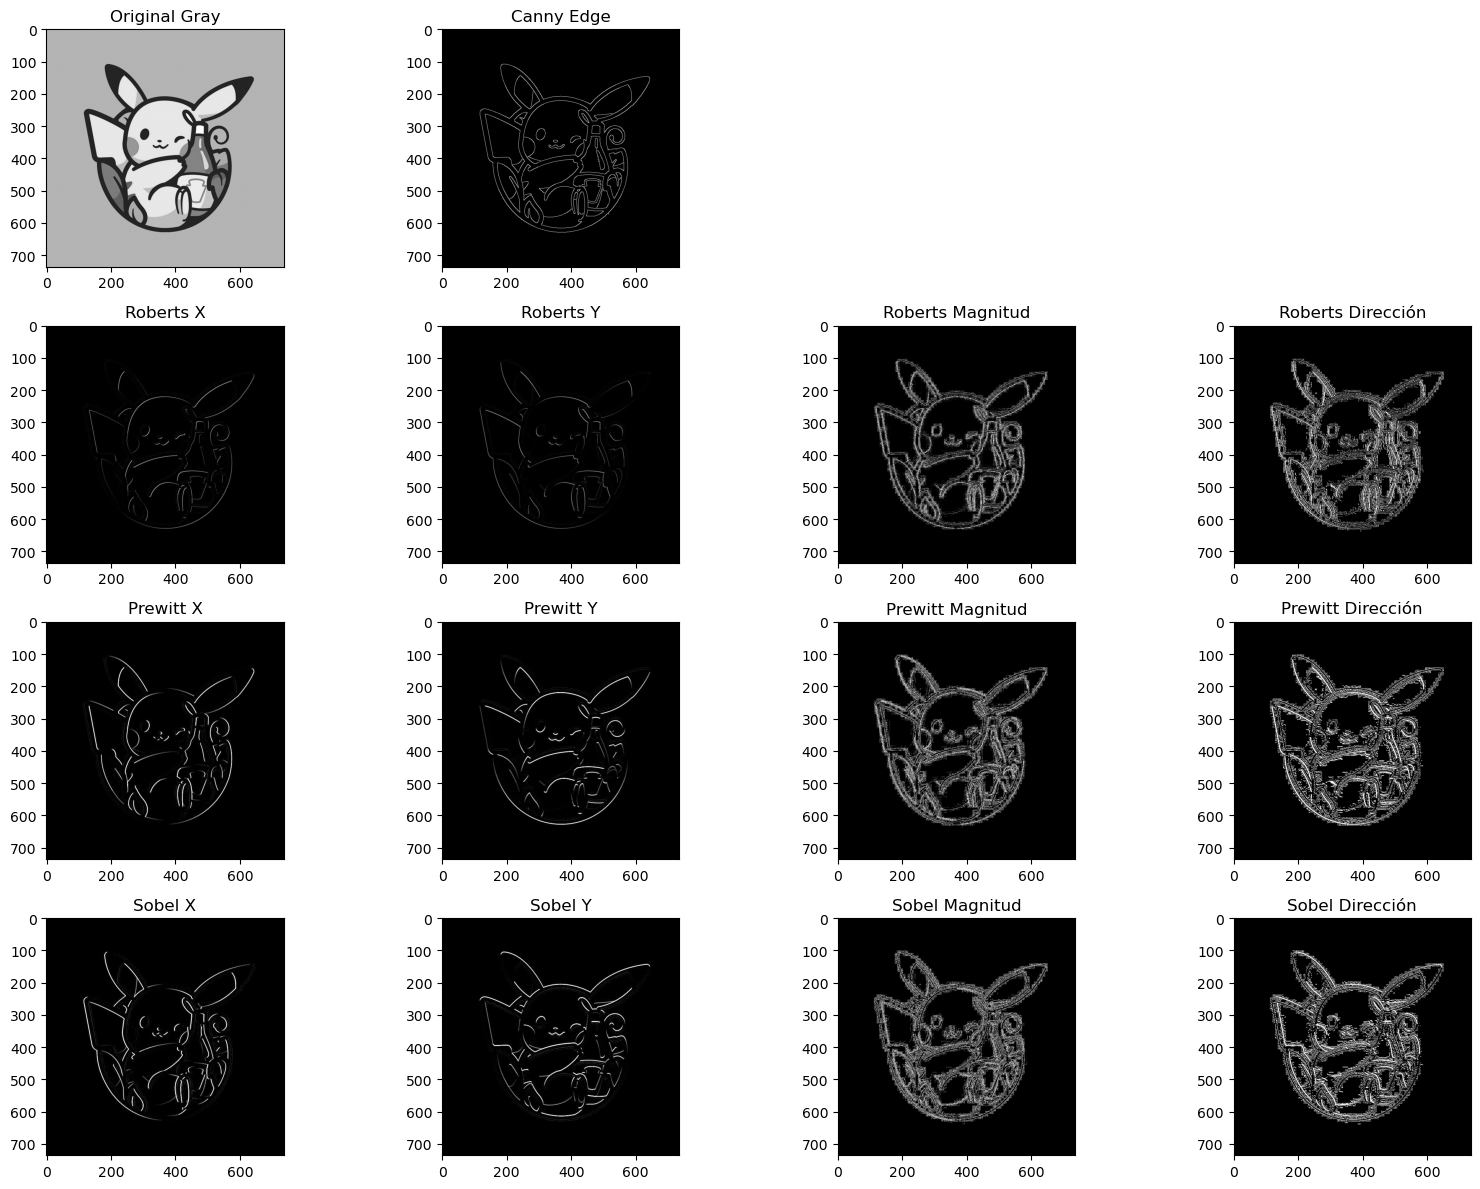

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('pikachu.jpg')
if img is None:
    print("Error: No se encontró la imagen 'pikachu.jpg'")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ROBERTS
    robertx = np.array([[-1, 0], [0, 1]])
    roberty = np.array([[0, -1], [1, 0]])
    robx_img = cv2.filter2D(gray, -1, robertx)
    roby_img = cv2.filter2D(gray, -1, roberty)
    rob_grad = np.sqrt(robx_img**2 + roby_img**2)
    rob_grad_dir = np.arctan2(roby_img, robx_img)

    # PREWITT
    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    
    prex_img = cv2.filter2D(gray, -1, prewitt_x)
    prey_img = cv2.filter2D(gray, -1, prewitt_y)
    
    prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
    prew_dir = np.arctan2(prey_img, prex_img)

    # SOBEL
    sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    
    sobelx_img = cv2.filter2D(gray, -1, sobel_x)
    sobely_img = cv2.filter2D(gray, -1, sobel_y)
    
    sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
    sobel_dir = np.arctan2(sobely_img, sobelx_img)

    # CANNY
    canny_img = cv2.Canny(gray, 50, 150)

    # VISUALIZACIÓN COMPLETA
    plt.figure(figsize=(16, 12))

    # Imagen Original y Canny
    plt.subplot(4, 4, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Gray')
    plt.subplot(4, 4, 2), plt.imshow(canny_img, cmap='gray'), plt.title('Canny Edge')

    # Roberts (X, Y, Magnitud, Dirección)
    plt.subplot(4, 4, 5), plt.imshow(robx_img, cmap='gray'), plt.title('Roberts X')
    plt.subplot(4, 4, 6), plt.imshow(roby_img, cmap='gray'), plt.title('Roberts Y')
    plt.subplot(4, 4, 7), plt.imshow(rob_grad, cmap='gray'), plt.title('Roberts Magnitud')
    plt.subplot(4, 4, 8), plt.imshow(rob_grad_dir, cmap='gray'), plt.title('Roberts Dirección')

    # Prewitt (X, Y, Magnitud, Dirección)
    plt.subplot(4, 4, 9), plt.imshow(prex_img, cmap='gray'), plt.title('Prewitt X')
    plt.subplot(4, 4, 10), plt.imshow(prey_img, cmap='gray'), plt.title('Prewitt Y')
    plt.subplot(4, 4, 11), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Prewitt Magnitud')
    plt.subplot(4, 4, 12), plt.imshow(prew_dir, cmap='gray'), plt.title('Prewitt Dirección')

    # Sobel (X, Y, Magnitud, Dirección)
    plt.subplot(4, 4, 13), plt.imshow(sobelx_img, cmap='gray'), plt.title('Sobel X')
    plt.subplot(4, 4, 14), plt.imshow(sobely_img, cmap='gray'), plt.title('Sobel Y')
    plt.subplot(4, 4, 15), plt.imshow(sobel_mag, cmap='gray'), plt.title('Sobel Magnitud')
    plt.subplot(4, 4, 16), plt.imshow(sobel_dir, cmap='gray'), plt.title('Sobel Dirección')

    plt.tight_layout()
    plt.show()

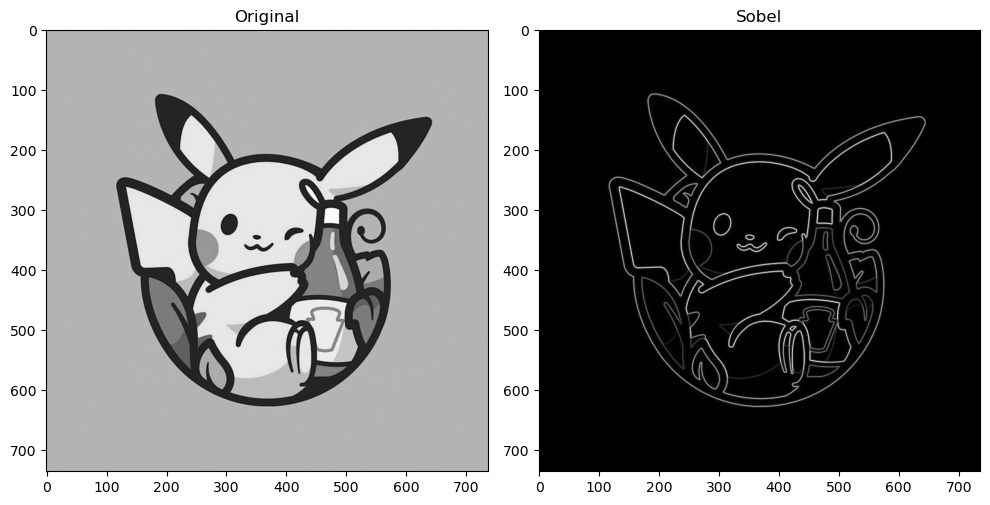

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    gx = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    
    mag = np.sqrt(np.square(gx) + np.square(gy))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag

img = cv2.imread('pikachu.jpg')

# Convertimos a gris antes para poder mostrarla en la gráfica
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

resultado = filtro_sobel(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gris, cmap='gray') 
plt.title('Original')
plt.axis

plt.subplot(1, 2, 2)
plt.imshow(resultado, cmap='gray')
plt.title('Sobel')
plt.axis

plt.tight_layout()
plt.show()

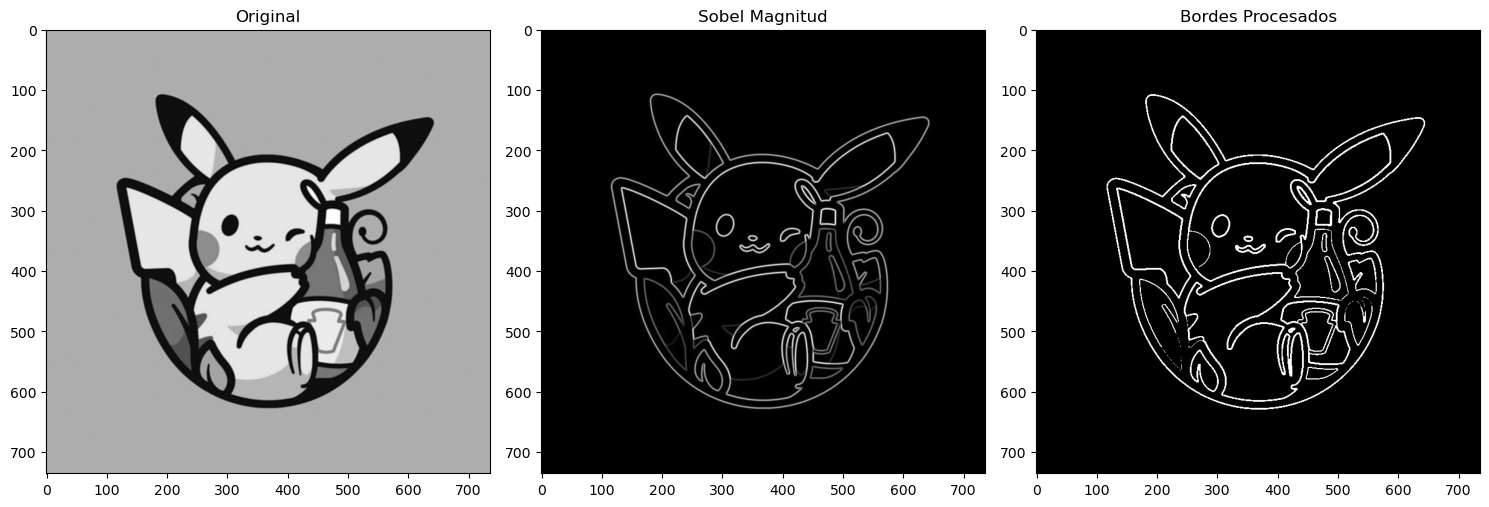

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion filtro gauss
    img_gris = cv2.GaussianBlur(img_gris, (3, 3), 0)
    
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)
    
    #mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _, borders = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #OPERACION MORPH UNIR BORDES ROTOS
    kernel = np.ones((2, 2), np.uint8)
    borders = cv2.morphologyEx(borders, cv2.MORPH_CLOSE, kernel)
    return img_gris, mag, borders

# Cargar imagen
img = cv2.imread('pikachu.jpg')

# Aplicar el filtro
img_gris, mag, bordes = filtro_sobel_mejorado(img, kernel_size=3, umbral=30)

# Mostrar resultados - Formato simple
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img_gris, cmap='gray'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(mag, cmap='gray'), plt.title('Sobel Magnitud')
plt.subplot(1, 3, 3), plt.imshow(bordes, cmap='gray'), plt.title('Bordes Procesados')
plt.tight_layout()
plt.show()

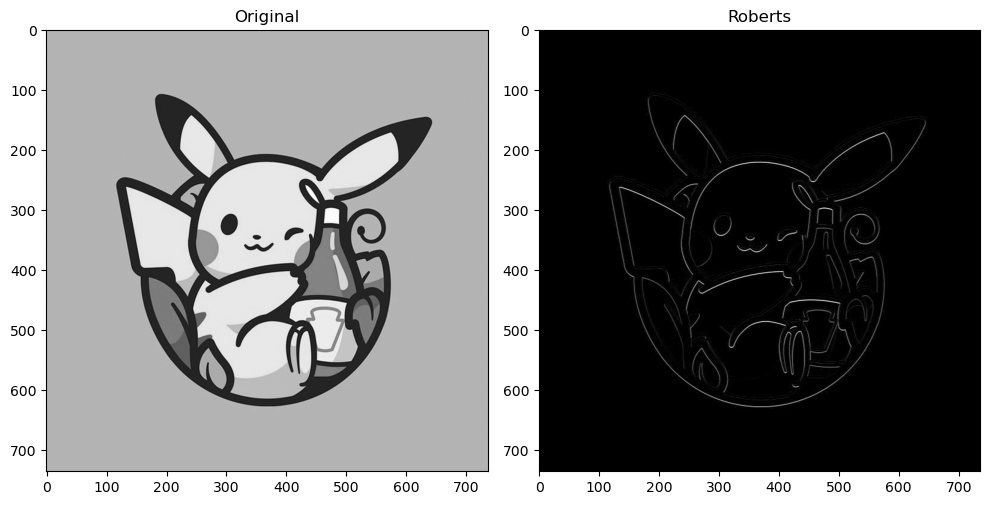

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]], dtype=np.float32)
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('pikachu.jpg')
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
resultado = filtro_roberts(img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img_gris, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(resultado, cmap='gray'), plt.title('Roberts')
plt.tight_layout()
plt.show()